In [1]:
!pip install anthropic -q

import anthropic
import base64
import json
import os
import pandas as pd
import numpy as np
from PIL import Image
import io
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

BASE          = '/content/drive/MyDrive/CDT_Dataset'
IMAGE_FOLDER  = f'{BASE}/images'
HUMAN_FOLDER  = f'{BASE}/images_human_fixed'
RESULT_FOLDER = f'{BASE}/results'
FEATURE_PATH  = f'{BASE}/labels/vqa_features.json'

os.makedirs(RESULT_FOLDER, exist_ok=True)

from google.colab import userdata
client = anthropic.Anthropic(
    api_key=userdata.get('ANTHROPIC_API_KEY')
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.9/923.9 kB 29.7 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
VQA_PROMPT = """
You are analyzing a Clock Drawing Test (CDT) image.
Answer each question with a specific number or Yes/No.
Be precise and consistent.

Return ONLY a JSON object, no explanation:
{
  "digit_count": <int 0-12>,
  "digits_present": <list of digits you can see>,
  "digit_positions_correct": <Yes/No>,
  "worst_quadrant": <"top-left"|"top-right"|"bottom-left"|"bottom-right"|"none">,
  "quadrant_balance": <int 0-4, how many quadrants have correct digits>,
  "has_hands": <Yes/No>,
  "hand_count": <int 0-3>,
  "hands_at_correct_position": <Yes/No>,
  "hour_hand_position": <int 0-12 or -1 if not visible>,
  "minute_hand_position": <int 0-12 or -1 if not visible>,
  "spatial_regularity": <int 1-5, 5=perfectly spaced>,
  "overall_quality": <int 1-5>
}
"""

def encode_image(img_path):
    try:
        img = Image.open(img_path).convert('RGB')
        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=95)
        return base64.standard_b64encode(
            buffer.getvalue()
        ).decode('utf-8')
    except Exception as e:
        print(f'Error encoding {img_path}: {e}')
        return None

def extract_vqa_features(img_path):
    img_b64 = encode_image(img_path)
    if img_b64 is None:
        return None

    try:
        response = client.messages.create(
            model='claude-haiku-4-5',
            max_tokens=500,
            messages=[{
                'role': 'user',
                'content': [
                    {
                        'type': 'image',
                        'source': {
                            'type'      : 'base64',
                            'media_type': 'image/jpeg',
                            'data'      : img_b64,
                        }
                    },
                    {
                        'type': 'text',
                        'text': VQA_PROMPT
                    }
                ]
            }]
        )

        text = response.content[0].text.strip()

        import re
        json_match = re.search(
            r'\{.*\}', text, re.DOTALL
        )
        if json_match:
            text = json_match.group()
        else:
            text = text.replace(
                '```json', ''
            ).replace('```', '').strip()

        features = json.loads(text)
        return features

    except json.JSONDecodeError as e:
        print(f'JSON Error: {e}')
        return None
    except Exception as e:
        print(f'Error: {e}')
        return None

print(f'\nFeatures ที่จะ extract:')
print('''
  digit_count              ← ช่วย Domain A
  digits_present           ← ช่วย Domain A
  digit_positions_correct  ← ช่วย Domain B
  worst_quadrant           ← ช่วย Domain B
  quadrant_balance         ← ช่วย Domain B
  has_hands                ← ช่วย Domain D
  hand_count               ← ช่วย Domain D
  hands_at_correct_position← ช่วย Domain E
  hour_hand_position       ← ช่วย Domain E
  minute_hand_position     ← ช่วย Domain E
  spatial_regularity       ← ช่วย Domain C
  overall_quality          ← ช่วยทุก domain
''')


Features ที่จะ extract:

  digit_count              ← ช่วย Domain A
  digits_present           ← ช่วย Domain A
  digit_positions_correct  ← ช่วย Domain B
  worst_quadrant           ← ช่วย Domain B
  quadrant_balance         ← ช่วย Domain B
  has_hands                ← ช่วย Domain D
  hand_count               ← ช่วย Domain D
  hands_at_correct_position← ช่วย Domain E
  hour_hand_position       ← ช่วย Domain E
  minute_hand_position     ← ช่วย Domain E
  spatial_regularity       ← ช่วย Domain C
  overall_quality          ← ช่วยทุก domain



In [ ]:
test_df = pd.read_csv(
    f'{BASE}/labels/human_test.csv'
)
sample_files = test_df['filename'].tolist()[:5]

for filename in sample_files:
    src = f'{HUMAN_FOLDER}/{filename}'
    if not os.path.exists(src):
        src = f'{IMAGE_FOLDER}/{filename.replace(".jpg",".tif")}'

    print(f'รูป: {filename}')
    features = extract_vqa_features(src)

    if features:
        print(f'  digit_count    : {features.get("digit_count")}')
        print(f'  has_hands      : {features.get("has_hands")}')
        print(f'  worst_quadrant : {features.get("worst_quadrant")}')
        print(f'  spatial_reg    : {features.get("spatial_regularity")}')
        print(f'  overall_quality: {features.get("overall_quality")}')
    else:
        print('  ดึง features ไม่ได้')
    print()

รูป: 40009857.jpg
  digit_count    : 12
  has_hands      : Yes
  worst_quadrant : none
  spatial_reg    : 4
  overall_quality: 4

รูป: 40009720.jpg
  digit_count    : 12
  has_hands      : Yes
  worst_quadrant : none
  spatial_reg    : 4
  overall_quality: 4

รูป: 30000175.jpg
  digit_count    : 12
  has_hands      : Yes
  worst_quadrant : none
  spatial_reg    : 4
  overall_quality: 4

รูป: 30003296.jpg
  digit_count    : 12
  has_hands      : Yes
  worst_quadrant : none
  spatial_reg    : 4
  overall_quality: 4

รูป: 40005572.jpg
  digit_count    : 12
  has_hands      : Yes
  worst_quadrant : none
  spatial_reg    : 4
  overall_quality: 4



In [ ]:
with open(FEATURE_PATH) as f:
    vqa_features = json.load(f)

total   = len(vqa_features)
success = sum(1 for v in vqa_features.values()
              if 'error' not in v)
error   = sum(1 for v in vqa_features.values()
              if 'error' in v)

print(f'ทั้งหมด : {total}')
print(f'สำเร็จ  : {success}')
print(f'Error   : {error}')

ทั้งหมด : 6602
สำเร็จ  : 6602
Error   : 0


In [ ]:
all_df = pd.read_csv(
    f'{BASE}/labels/human_labels.csv'
)

print(f'รูปทั้งหมด: {len(all_df)}')

if os.path.exists(FEATURE_PATH):
    with open(FEATURE_PATH) as f:
        vqa_features = json.load(f)
    print(f'มี progress เดิม: {len(vqa_features)} รูป')
else:
    vqa_features = {}
    print('เริ่มใหม่')

remaining = [
    row for _, row in all_df.iterrows()
    if row['filename'] not in vqa_features
    or 'error' in vqa_features.get(
        row['filename'], {}
    )
]

print(f'ยังต้อง extract: {len(remaining)} รูป')
print(f'ประมาณ: {len(remaining)*2/60:.1f} นาที '
      f'(~2 วิ/รูป)')

error_count = 0

for row in tqdm(remaining):
    filename = row['filename']

    src_human = f'{HUMAN_FOLDER}/{filename}'
    src_orig  = f'{IMAGE_FOLDER}/{filename.replace(".jpg",".tif")}'

    if os.path.exists(src_human):
        src_path = src_human
    elif os.path.exists(src_orig):
        src_path = src_orig
    else:
        error_count += 1
        continue

    features = extract_vqa_features(src_path)

    if features:
        vqa_features[filename] = features
    else:
        error_count += 1
        vqa_features[filename] = {'error': True}

    if len(vqa_features) % 50 == 0:
        with open(FEATURE_PATH, 'w') as f:
            json.dump(vqa_features, f)

with open(FEATURE_PATH, 'w') as f:
    json.dump(vqa_features, f, indent=2)

success = sum(
    1 for v in vqa_features.values()
    if 'error' not in v
)
print(f'  สำเร็จ: {success} รูป')
print(f'  Error : {error_count} รูป')

รูปทั้งหมด: 6602
มี progress เดิม: 6602 รูป
ยังต้อง extract: 0 รูป
ประมาณ: 0.0 นาที (~2 วิ/รูป)


0it [00:00, ?it/s]

  สำเร็จ: 6602 รูป
  Error : 0 รูป


In [ ]:
def features_to_vector(features):
    """
    แปลง VQA features เป็น numeric vector
    สำหรับใส่เข้า model
    """
    if features is None or 'error' in features:
        return np.zeros(12)

    vec = []
    vec.append(
        features.get('digit_count', 0) / 12.0
    )

    digits = features.get('digits_present', [])
    vec.append(len(digits) / 12.0)

    vec.append(
        1.0 if features.get(
            'digit_positions_correct'
        ) == 'Yes' else 0.0
    )

    vec.append(
        features.get('quadrant_balance', 0) / 4.0
    )

    wq = features.get('worst_quadrant', 'none')
    wq_map = {
        'top-left'    : [1,0,0,0,0],
        'top-right'   : [0,1,0,0,0],
        'bottom-left' : [0,0,1,0,0],
        'bottom-right': [0,0,0,1,0],
        'none'        : [0,0,0,0,1],
    }
    vec.extend(wq_map.get(wq, [0,0,0,0,1]))

    vec.append(
        1.0 if features.get(
            'has_hands'
        ) == 'Yes' else 0.0
    )

    vec.append(
        features.get('hand_count', 0) / 3.0
    )

    vec.append(
        1.0 if features.get(
            'hands_at_correct_position'
        ) == 'Yes' else 0.0
    )

    vec.append(
        features.get('spatial_regularity', 1) / 5.0
    )

    vec.append(
        features.get('overall_quality', 1) / 5.0
    )

    return np.array(vec, dtype=np.float32)

sample_feat = list(vqa_features.values())[0]
vec         = features_to_vector(sample_feat)
print(f'Feature vector shape: {vec.shape}')
print(f'Feature vector: {vec}')
print(f'\nFeature dimension = {len(vec)}')

Feature vector shape: (14,)
Feature vector: [1.        1.        0.        0.5       0.        0.        1.
 0.        0.        1.        0.6666667 0.        0.4       0.4      ]

Feature dimension = 14


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CDTHybridDataset(Dataset):
    """Dataset ที่มีทั้ง image และ VQA features"""

    def __init__(self, df, image_folder,
                 vqa_features, aug_folder=None,
                 transform=None):
        self.df           = df.reset_index(drop=True)
        self.image_folder = image_folder
        self.vqa_features = vqa_features
        self.aug_folder   = aug_folder
        self.transform    = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        filename = row['filename']

        if (self.aug_folder and
                filename.startswith('aug')):
            img_path = f'{self.aug_folder}/{filename}'
        else:
            img_path = f'{self.image_folder}/{filename}'

        try:
            img = Image.open(img_path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224),
                           (255, 255, 255))

        if self.transform:
            img = self.transform(img)

        feat_dict = self.vqa_features.get(
            filename, {}
        )
        feat_vec  = torch.tensor(
            features_to_vector(feat_dict),
            dtype=torch.float32
        )

        labels = torch.tensor([
            row['domain_A'], row['domain_B'],
            row['domain_C'], row['domain_D'],
            row['domain_E']
        ], dtype=torch.float32)

        return img, feat_vec, labels

print(f'Feature vector dim: {len(features_to_vector({}))}')

Feature vector dim: 14


In [ ]:
import torch.nn as nn
import timm
from torchvision import models

FEATURE_DIM = len(features_to_vector({}))
print(f'VQA feature dim: {FEATURE_DIM}')

class CDTHybridModel(nn.Module):
    """
    Vision backbone + VQA features
    """
    def __init__(self, backbone_name='vit',
                 vqa_dim=FEATURE_DIM,
                 num_domains=5):
        super().__init__()

        if backbone_name == 'vit':
            self.backbone = timm.create_model(
                'vit_base_patch16_224',
                pretrained=True,
                num_classes=0
            )
            vis_dim = 768
        else:
            backbone = models.resnet50(
                weights=models.ResNet50_Weights.IMAGENET1K_V1
            )
            self.backbone = nn.Sequential(
                *list(backbone.children())[:-1]
            )
            vis_dim = 2048

        self.backbone_name = backbone_name

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.vis_shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(vis_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.vqa_encoder = nn.Sequential(
            nn.Linear(vqa_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.fusion = nn.Sequential(
            nn.Linear(512 + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.heads_reg = nn.ModuleList([
            nn.Linear(256, 1)
            for _ in range(num_domains)
        ])

        self.heads_cls = nn.ModuleList([
            nn.Linear(256, 3)
            for _ in range(num_domains)
        ])

    def forward(self, img, vqa_feat, mode='reg'):
        if self.backbone_name == 'vit':
            vis = self.backbone(img)
            vis = vis.unsqueeze(-1).unsqueeze(-1)
        else:
            vis = self.backbone(img)

        vis = self.vis_shared(vis)

        vqa = self.vqa_encoder(vqa_feat)

        fused = self.fusion(
            torch.cat([vis, vqa], dim=1)
        )

        if mode == 'reg':
            return [
                head(fused).squeeze(-1)
                for head in self.heads_reg
            ]
        else:
            return [
                head(fused)
                for head in self.heads_cls
            ]

device     = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
test_model = CDTHybridModel('vit').to(device)
dummy_img  = torch.randn(2, 3, 224, 224).to(device)
dummy_vqa  = torch.randn(2, FEATURE_DIM).to(device)
out        = test_model(dummy_img, dummy_vqa)
print(f'Output shapes: {[o.shape for o in out]}')

VQA feature dim: 14


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Output shapes: [torch.Size([2]), torch.Size([2]), torch.Size([2]), torch.Size([2]), torch.Size([2])]


In [ ]:
MODEL_FOLDER_HYBRID = f'{BASE}/models_hybrid'
os.makedirs(MODEL_FOLDER_HYBRID, exist_ok=True)

CUTOFF      = 6
AUG_FOLDER  = f'{BASE}/images_human_aug'

train_df = pd.read_csv(
    f'{BASE}/labels/human_train.csv'
)
val_df   = pd.read_csv(
    f'{BASE}/labels/human_val.csv'
)
test_df  = pd.read_csv(
    f'{BASE}/labels/human_test.csv'
)

for d in [train_df, val_df, test_df]:
    d['dementia_risk'] = d['dementia_risk'].astype(bool)

TARGET_NORMAL   = 2000
TARGET_DEMENTIA = 1200

dementia_df    = train_df[train_df['dementia_risk']]
normal_df      = train_df[~train_df['dementia_risk']]
normal_sampled = normal_df.sample(
    n=min(TARGET_NORMAL, len(normal_df)),
    random_state=42
)

need_more = max(
    0, TARGET_DEMENTIA - len(dementia_df)
)
aug_rows  = []
generated = 0

if need_more > 0:
    from PIL import ImageEnhance
    import random

    while generated < need_more:
        for _, row in dementia_df.iterrows():
            if generated >= need_more:
                break
            try:
                src = (f'{HUMAN_FOLDER}/'
                       f'{row["filename"]}')
                img = Image.open(src).convert('RGB')

                factor = random.uniform(0.8, 1.2)
                img    = ImageEnhance.Brightness(
                    img
                ).enhance(factor)

                new_name = (
                    f'aug_h_{generated:05d}_'
                    f'{row["filename"]}'
                )
                img.save(
                    f'{AUG_FOLDER}/{new_name}',
                    'JPEG', quality=95
                )

                vqa_features[new_name] = vqa_features.get(
                    row['filename'], {}
                )

                new_row             = row.copy()
                new_row['filename'] = new_name
                aug_rows.append(new_row)
                generated += 1
            except:
                continue

    aug_df      = pd.DataFrame(aug_rows)
    dementia_df = pd.concat(
        [dementia_df, aug_df], ignore_index=True
    )

train_df_balanced = pd.concat(
    [normal_sampled, dementia_df],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(
    drop=True
)

print(f'Train: {len(train_df_balanced)} รูป')
print(f'  Normal  : {(~train_df_balanced["dementia_risk"]).sum()}')
print(f'  Dementia: {train_df_balanced["dementia_risk"].sum()}')

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

train_ds = CDTHybridDataset(
    train_df_balanced, HUMAN_FOLDER,
    vqa_features, AUG_FOLDER, train_transform
)
val_ds = CDTHybridDataset(
    val_df, HUMAN_FOLDER,
    vqa_features, None, val_transform
)
test_ds = CDTHybridDataset(
    test_df, HUMAN_FOLDER,
    vqa_features, None, val_transform
)

train_loader = DataLoader(
    train_ds, batch_size=16,
    shuffle=True, num_workers=2
)
val_loader = DataLoader(
    val_ds, batch_size=16,
    shuffle=False, num_workers=2
)
test_loader = DataLoader(
    test_ds, batch_size=16,
    shuffle=False, num_workers=2
)

Train: 3200 รูป
  Normal  : 2000
  Dementia: 1200


In [ ]:
import torch.optim as optim
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    f1_score, accuracy_score,
    mean_absolute_error
)

DOMAIN_WEIGHTS = torch.tensor(
    [1.0, 1.5, 1.0, 1.0, 1.0]
).to(device)

def compute_loss(outputs, labels, mode='reg'):
    total = 0
    for i, output in enumerate(outputs):
        if mode == 'reg':
            loss = nn.MSELoss()(
                output, labels[:, i].float()
            )
        else:
            loss = nn.CrossEntropyLoss()(
                output, labels[:, i].long()
            )
        total += loss * DOMAIN_WEIGHTS[i]
    return total / DOMAIN_WEIGHTS.sum()

def get_predictions(outputs, mode='reg'):
    preds = []
    for output in outputs:
        if mode == 'reg':
            pred = output.round().clamp(0, 2).long()
        else:
            pred = output.argmax(dim=1)
        preds.append(pred)
    return torch.stack(preds, dim=1)

def evaluate_hybrid(model, loader, mode='reg'):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, vqa_feat, labels in loader:
            images   = images.to(device)
            vqa_feat = vqa_feat.to(device)
            outputs  = model(images, vqa_feat, mode)
            preds    = get_predictions(outputs, mode)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    pred_total    = all_preds.sum(axis=1)
    true_total    = all_labels.sum(axis=1)
    pred_dementia = (pred_total < CUTOFF).astype(int)
    true_dementia = (true_total < CUTOFF).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_dementia, pred_dementia, labels=[0,1]
    ).ravel()

    sens = tp/(tp+fn) if (tp+fn) > 0 else 0
    spec = tn/(tn+fp) if (tn+fp) > 0 else 0
    try:
        auc = roc_auc_score(
            true_dementia, -pred_total
        )
    except:
        auc = 0

    return {
        'sensitivity': sens,
        'specificity': spec,
        'auc'        : auc,
        'pred_total' : pred_total,
        'true_dementia': true_dementia,
    }


# Train
model_name = 'hybrid_vit_reg'
path       = f'{MODEL_FOLDER_HYBRID}/{model_name}_best.pth'

if os.path.exists(path):
    print(f'โหลด {model_name}')
    model = CDTHybridModel('vit').to(device)
    model.load_state_dict(
        torch.load(path, map_location=device)
    )
    model.eval()
else:
    print(f'Train {model_name}')

    model     = CDTHybridModel('vit').to(device)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad,
               model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )

    best_combined = -1
    best_state    = None
    no_improve    = 0
    epochs        = 20
    patience      = 10

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, vqa_feat, labels in train_loader:
            images   = images.to(device)
            vqa_feat = vqa_feat.to(device)
            labels   = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images, vqa_feat, 'reg')
            loss    = compute_loss(outputs, labels, 'reg')
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        val_results = evaluate_hybrid(
            model, val_loader, 'reg'
        )

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, vqa_feat, labels in val_loader:
                images   = images.to(device)
                vqa_feat = vqa_feat.to(device)
                labels   = labels.to(device)
                outputs  = model(
                    images, vqa_feat, 'reg'
                )
                loss     = compute_loss(
                    outputs, labels, 'reg'
                )
                val_loss += loss.item()
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        combined = (
            val_results['sensitivity'] +
            val_results['specificity']
        ) / 2

        if combined > best_combined:
            best_combined = combined
            best_state    = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop epoch {epoch+1}')
                break

        print(f'Epoch {epoch+1:2d}/{epochs} | '
              f'Loss: {train_loss:.4f}/{val_loss:.4f} | '
              f'Sens: {val_results["sensitivity"]:.3f} | '
              f'Spec: {val_results["specificity"]:.3f} | '
              f'AUC: {val_results["auc"]:.3f}')

    model.load_state_dict(best_state)
    torch.save(
        best_state,
        f'{MODEL_FOLDER_HYBRID}/{model_name}_best.pth'
    )
    print(f'บันทึก {model_name} แล้ว')

โหลด hybrid_vit_reg


In [ ]:
test_results = evaluate_hybrid(
    model, test_loader, 'reg'
)

vit_reg_07k = {
    'sensitivity': 0.751,
    'specificity': 0.844,
    'auc'        : 0.882,
}

print('='*65)
print('COMPARISON: 07k ViT REG vs Hybrid ViT REG')
print('='*65)
print(f'{"Metric":<20} {"07k ViT REG":>15} '
      f'{"Hybrid":>15} {"Better?":>10}')
print('='*65)

for metric in ['sensitivity', 'specificity', 'auc']:
    old = vit_reg_07k[metric]
    new = test_results[metric]
    better = '✅' if new > old else '⚠️'
    diff   = new - old
    print(f'{metric:<20} {old:>15.3f} '
          f'{new:>15.3f} '
          f'{better} ({diff:+.3f})')

print('='*65)

pred_total    = test_results['pred_total']
true_dementia = test_results['true_dementia']

print(f'\nCutoff Analysis — Hybrid Model:')
print(f'{"Cutoff":>8} {"Sens":>8} '
      f'{"Spec":>8} {"AUC":>8}')
print('-'*38)

for cutoff in [5, 6, 7, 8]:
    pred = (pred_total < cutoff).astype(int)
    try:
        tn, fp, fn, tp = confusion_matrix(
            true_dementia, pred, labels=[0,1]
        ).ravel()
        sens = tp/(tp+fn) if (tp+fn) > 0 else 0
        spec = tn/(tn+fp) if (tn+fp) > 0 else 0
        auc  = roc_auc_score(
            true_dementia, -pred_total
        )
    except:
        sens, spec, auc = 0, 0, 0

    mark = '✅' if (
        sens >= 0.88 and spec >= 0.82
    ) else '⚠️'
    print(f'{cutoff:>8} {sens:>8.3f} '
          f'{spec:>8.3f} {auc:>8.3f} {mark}')

with open(
    f'{RESULT_FOLDER}/07l_hybrid_results.json', 'w'
) as f:
    json.dump({
        'model'      : 'hybrid_vit_reg',
        'vqa_features': FEATURE_DIM,
        'sensitivity': float(test_results['sensitivity']),
        'specificity': float(test_results['specificity']),
        'auc'        : float(test_results['auc']),
        'vs_07k'     : {
            'auc_diff': float(
                test_results['auc'] - vit_reg_07k['auc']
            )
        }
    }, f, indent=2)

COMPARISON: 07k ViT REG vs Hybrid ViT REG
Metric                   07k ViT REG          Hybrid    Better?
sensitivity                    0.751           0.760 ✅ (+0.009)
specificity                    0.844           0.850 ✅ (+0.006)
auc                            0.882           0.886 ✅ (+0.004)

Cutoff Analysis — Hybrid Model:
  Cutoff     Sens     Spec      AUC
--------------------------------------
       5    0.582    0.954    0.886 ⚠️
       6    0.760    0.850    0.886 ⚠️
       7    0.800    0.805    0.886 ⚠️
       8    0.960    0.490    0.886 ⚠️


In [ ]:
hybrid_preds  = []
hybrid_labels = []
hybrid_raw    = []

model.eval()
with torch.no_grad():
    for images, vqa_feat, labels in test_loader:
        images   = images.to(device)
        vqa_feat = vqa_feat.to(device)
        outputs  = model(images, vqa_feat, 'reg')

        raw = torch.stack(
            [o.squeeze(-1) for o in outputs], dim=1
        )
        preds = get_predictions(outputs, 'reg')

        hybrid_raw.append(raw.cpu())
        hybrid_preds.append(preds.cpu())
        hybrid_labels.append(labels.cpu())

hybrid_raw    = torch.cat(hybrid_raw).numpy()
hybrid_preds  = torch.cat(hybrid_preds).numpy()
hybrid_labels = torch.cat(hybrid_labels).numpy()

print(f'Predictions shape: {hybrid_preds.shape}')

Predictions shape: (1328, 5)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import torch
import torch.nn as nn
import timm
from torchvision import models

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

class CDTModel(nn.Module):
    def __init__(self, backbone_name='resnet50',
                 num_domains=5, num_classes=3):
        super().__init__()

        if backbone_name == 'resnet50':
            backbone = models.resnet50(
                weights=models.ResNet50_Weights.IMAGENET1K_V1
            )
            self.feature_dim = 2048
            for param in backbone.parameters():
                param.requires_grad = False
            self.backbone = nn.Sequential(
                *list(backbone.children())[:-1]
            )
        elif backbone_name == 'vit':
            self.backbone = timm.create_model(
                'vit_base_patch16_224',
                pretrained=True,
                num_classes=0
            )
            self.feature_dim = 768
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.backbone_name = backbone_name
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.heads_cls = nn.ModuleList([
            nn.Linear(512, num_classes)
            for _ in range(num_domains)
        ])
        self.heads_reg = nn.ModuleList([
            nn.Linear(512, 1)
            for _ in range(num_domains)
        ])

    def forward(self, x, mode='reg'):
        if self.backbone_name == 'resnet50':
            feat = self.backbone(x)
        else:
            feat = self.backbone(x)
            feat = feat.unsqueeze(-1).unsqueeze(-1)
        feat = self.shared(feat)
        if mode == 'reg':
            return [head(feat).squeeze(-1)
                    for head in self.heads_reg]
        else:
            return [head(feat)
                    for head in self.heads_cls]

print(f'Device: {device}')

Device: cuda


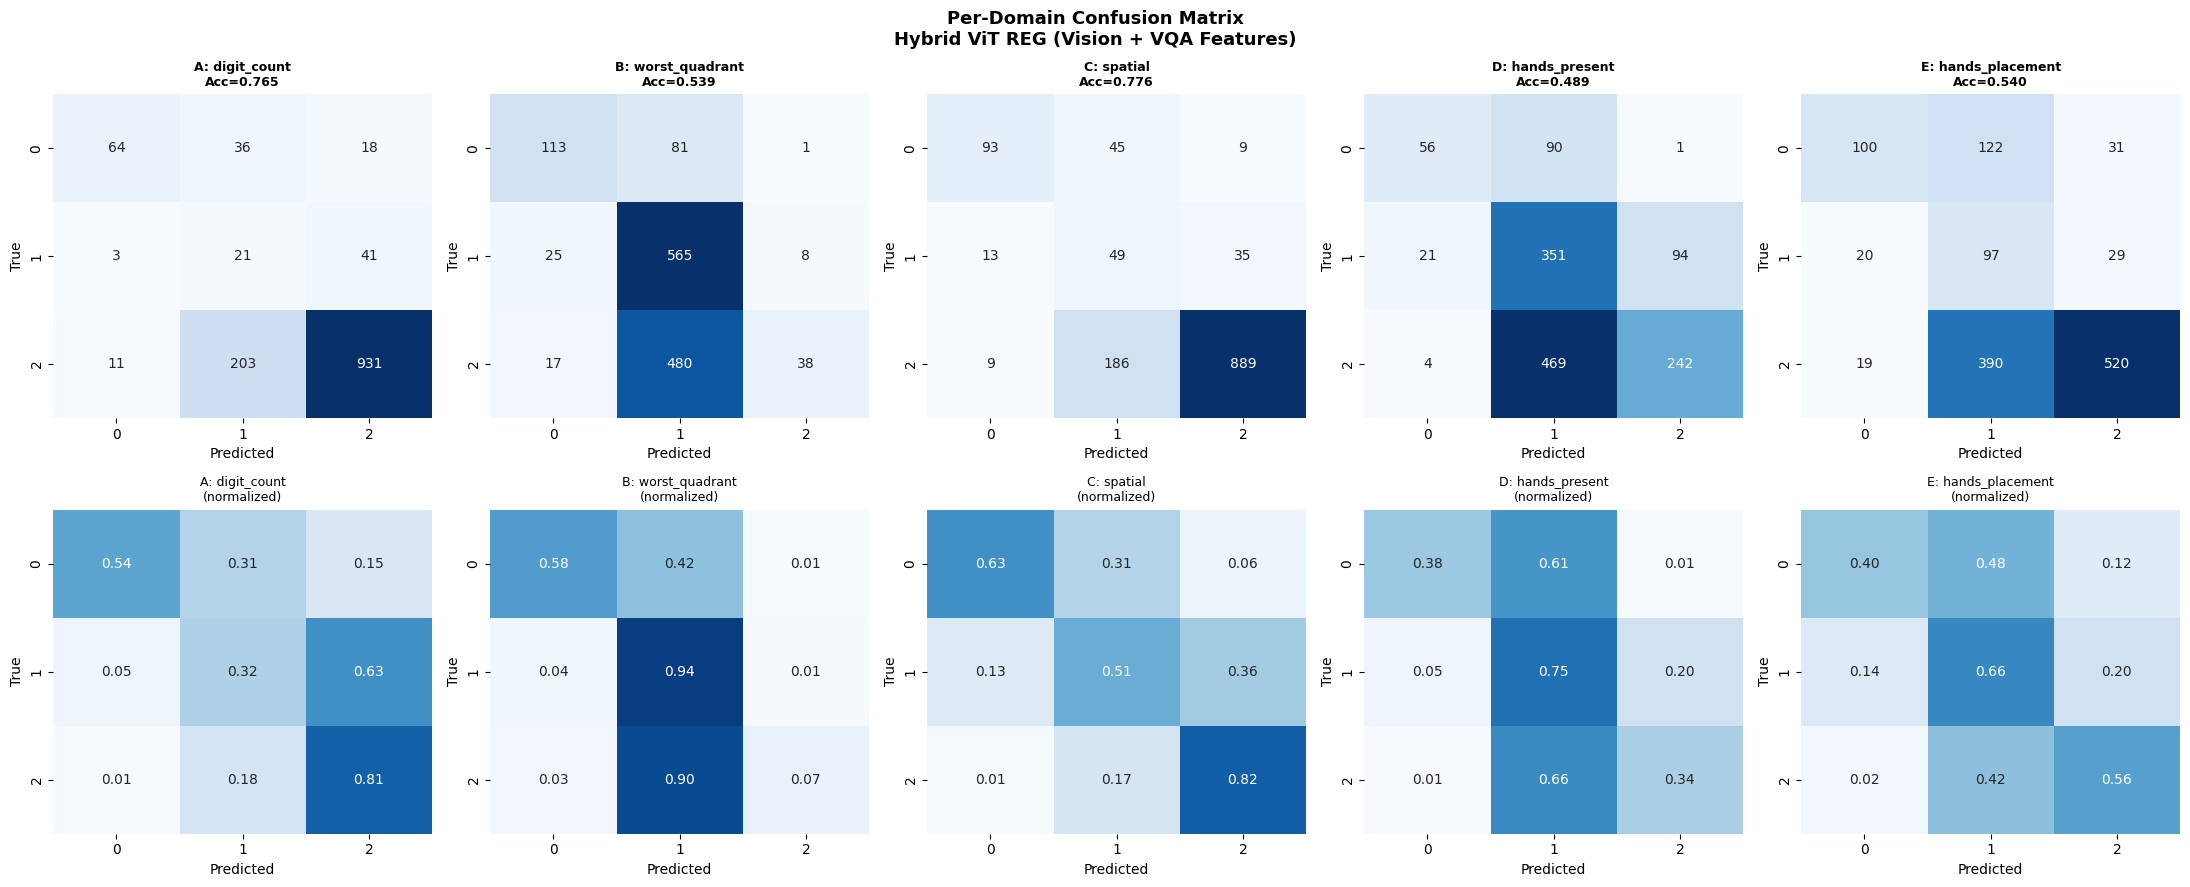

In [ ]:
domain_names = {
    0: 'A: digit_count',
    1: 'B: worst_quadrant',
    2: 'C: spatial',
    3: 'D: hands_present',
    4: 'E: hands_placement',
}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for d_idx, d_name in domain_names.items():
    true_d = hybrid_labels[:, d_idx].astype(int)
    pred_d = hybrid_preds[:, d_idx].astype(int)

    cm      = confusion_matrix(
        true_d, pred_d, labels=[0,1,2]
    )
    cm_norm = cm.astype(float)
    row_sum = cm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    cm_norm = cm_norm / row_sum

    ax_raw  = axes[0][d_idx]
    ax_norm = axes[1][d_idx]

    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Blues', ax=ax_raw,
        xticklabels=['0','1','2'],
        yticklabels=['0','1','2'],
        cbar=False
    )
    acc = (true_d == pred_d).mean()
    ax_raw.set_title(
        f'{d_name}\nAcc={acc:.3f}',
        fontsize=9, fontweight='bold'
    )
    ax_raw.set_xlabel('Predicted')
    ax_raw.set_ylabel('True')

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f',
        cmap='Blues', ax=ax_norm,
        xticklabels=['0','1','2'],
        yticklabels=['0','1','2'],
        cbar=False, vmin=0, vmax=1
    )
    ax_norm.set_title(
        f'{d_name}\n(normalized)',
        fontsize=9
    )
    ax_norm.set_xlabel('Predicted')
    ax_norm.set_ylabel('True')

plt.suptitle(
    'Per-Domain Confusion Matrix\n'
    'Hybrid ViT REG (Vision + VQA Features)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07l_confusion_matrix.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import timm
import pandas as pd
import numpy as np
import json
import os
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    accuracy_score, mean_absolute_error
)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

BASE          = '/content/drive/MyDrive/CDT_Dataset'
HUMAN_FOLDER  = f'{BASE}/images_human_fixed'
IMAGE_FOLDER  = f'{BASE}/images'
RESULT_FOLDER = f'{BASE}/results'
AUG_FOLDER    = f'{BASE}/images_human_aug'
FEATURE_PATH  = f'{BASE}/labels/vqa_features.json'
MODEL_FOLDER  = f'{BASE}/models_hybrid'
MODEL_FOLDER_US = f'{BASE}/models_human_undersample'

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
CUTOFF = 6

class CDTDataset(Dataset):
    def __init__(self, df, image_folder,
                 aug_folder=None, transform=None):
        self.df           = df.reset_index(drop=True)
        self.image_folder = image_folder
        self.aug_folder   = aug_folder
        self.transform    = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        filename = row['filename']

        if (self.aug_folder and
                filename.startswith('aug')):
            img_path = f'{self.aug_folder}/{filename}'
        else:
            img_path = f'{self.image_folder}/{filename}'

        try:
            img = Image.open(img_path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224),
                           (255, 255, 255))

        if self.transform:
            img = self.transform(img)

        labels = torch.tensor([
            row['domain_A'], row['domain_B'],
            row['domain_C'], row['domain_D'],
            row['domain_E']
        ], dtype=torch.float32)

        return img, labels

class CDTModel(nn.Module):
    def __init__(self, backbone_name='resnet50',
                 num_domains=5, num_classes=3):
        super().__init__()

        if backbone_name == 'resnet50':
            backbone = models.resnet50(
                weights=models.ResNet50_Weights.IMAGENET1K_V1
            )
            self.feature_dim = 2048
            for param in backbone.parameters():
                param.requires_grad = False
            self.backbone = nn.Sequential(
                *list(backbone.children())[:-1]
            )
        elif backbone_name == 'vit':
            self.backbone = timm.create_model(
                'vit_base_patch16_224',
                pretrained=True,
                num_classes=0
            )
            self.feature_dim = 768
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.backbone_name = backbone_name
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.heads_cls = nn.ModuleList([
            nn.Linear(512, num_classes)
            for _ in range(num_domains)
        ])
        self.heads_reg = nn.ModuleList([
            nn.Linear(512, 1)
            for _ in range(num_domains)
        ])

    def forward(self, x, mode='reg'):
        if self.backbone_name == 'resnet50':
            feat = self.backbone(x)
        else:
            feat = self.backbone(x)
            feat = feat.unsqueeze(-1).unsqueeze(-1)
        feat = self.shared(feat)
        if mode == 'reg':
            return [head(feat).squeeze(-1)
                    for head in self.heads_reg]
        else:
            return [head(feat)
                    for head in self.heads_cls]

class CDTHybridModel(nn.Module):
    def __init__(self, backbone_name='vit',
                 vqa_dim=12, num_domains=5):
        super().__init__()

        if backbone_name == 'vit':
            self.backbone = timm.create_model(
                'vit_base_patch16_224',
                pretrained=True,
                num_classes=0
            )
            vis_dim = 768
        else:
            backbone = models.resnet50(
                weights=models.ResNet50_Weights.IMAGENET1K_V1
            )
            self.backbone = nn.Sequential(
                *list(backbone.children())[:-1]
            )
            vis_dim = 2048

        self.backbone_name = backbone_name

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.vis_shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(vis_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.vqa_encoder = nn.Sequential(
            nn.Linear(vqa_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.fusion = nn.Sequential(
            nn.Linear(512 + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.heads_reg = nn.ModuleList([
            nn.Linear(256, 1)
            for _ in range(num_domains)
        ])
        self.heads_cls = nn.ModuleList([
            nn.Linear(256, 3)
            for _ in range(num_domains)
        ])

    def forward(self, img, vqa_feat, mode='reg'):
        if self.backbone_name == 'vit':
            vis = self.backbone(img)
            vis = vis.unsqueeze(-1).unsqueeze(-1)
        else:
            vis = self.backbone(img)

        vis   = self.vis_shared(vis)
        vqa   = self.vqa_encoder(vqa_feat)
        fused = self.fusion(
            torch.cat([vis, vqa], dim=1)
        )

        if mode == 'reg':
            return [
                head(fused).squeeze(-1)
                for head in self.heads_reg
            ]
        else:
            return [
                head(fused)
                for head in self.heads_cls
            ]


def get_predictions(outputs, mode='reg'):
    preds = []
    for output in outputs:
        if mode == 'reg':
            pred = output.round().clamp(0, 2).long()
        else:
            pred = output.argmax(dim=1)
        preds.append(pred)
    return torch.stack(preds, dim=1)


val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])


test_df  = pd.read_csv(f'{BASE}/labels/human_test.csv')
train_df = pd.read_csv(f'{BASE}/labels/human_train.csv')
val_df   = pd.read_csv(f'{BASE}/labels/human_val.csv')

for d in [test_df, train_df, val_df]:
    d['dementia_risk'] = d['dementia_risk'].astype(bool)

with open(FEATURE_PATH) as f:
    vqa_features = json.load(f)

def features_to_vector(features):
    if features is None or 'error' in features:
        return np.zeros(12)
    vec = []
    vec.append(features.get('digit_count', 0) / 12.0)
    digits = features.get('digits_present', [])
    vec.append(len(digits) / 12.0)
    vec.append(1.0 if features.get(
        'digit_positions_correct') == 'Yes' else 0.0)
    vec.append(features.get('quadrant_balance', 0) / 4.0)
    wq = features.get('worst_quadrant', 'none')
    wq_map = {
        'top-left'    : [1,0,0,0,0],
        'top-right'   : [0,1,0,0,0],
        'bottom-left' : [0,0,1,0,0],
        'bottom-right': [0,0,0,1,0],
        'none'        : [0,0,0,0,1],
    }
    vec.extend(wq_map.get(wq, [0,0,0,0,1]))
    vec.append(1.0 if features.get(
        'has_hands') == 'Yes' else 0.0)
    vec.append(features.get('hand_count', 0) / 3.0)
    vec.append(1.0 if features.get(
        'hands_at_correct_position') == 'Yes' else 0.0)
    vec.append(features.get(
        'spatial_regularity', 1) / 5.0)
    vec.append(features.get(
        'overall_quality', 1) / 5.0)
    return np.array(vec, dtype=np.float32)

domain_names = {
    0: 'A: digit_count',
    1: 'B: worst_quadrant',
    2: 'C: spatial',
    3: 'D: hands_present',
    4: 'E: hands_placement',
}
colors_true = {
    0: '#3F51B5',
    1: '#00BCD4',
    2: '#8BC34A',
}

print(f'Device: {device}')
print(f'Test  : {len(test_df)} รูป')
print(f'VQA   : {len(vqa_features)} features')

Device: cuda
Test  : 1328 รูป
VQA   : 6602 features


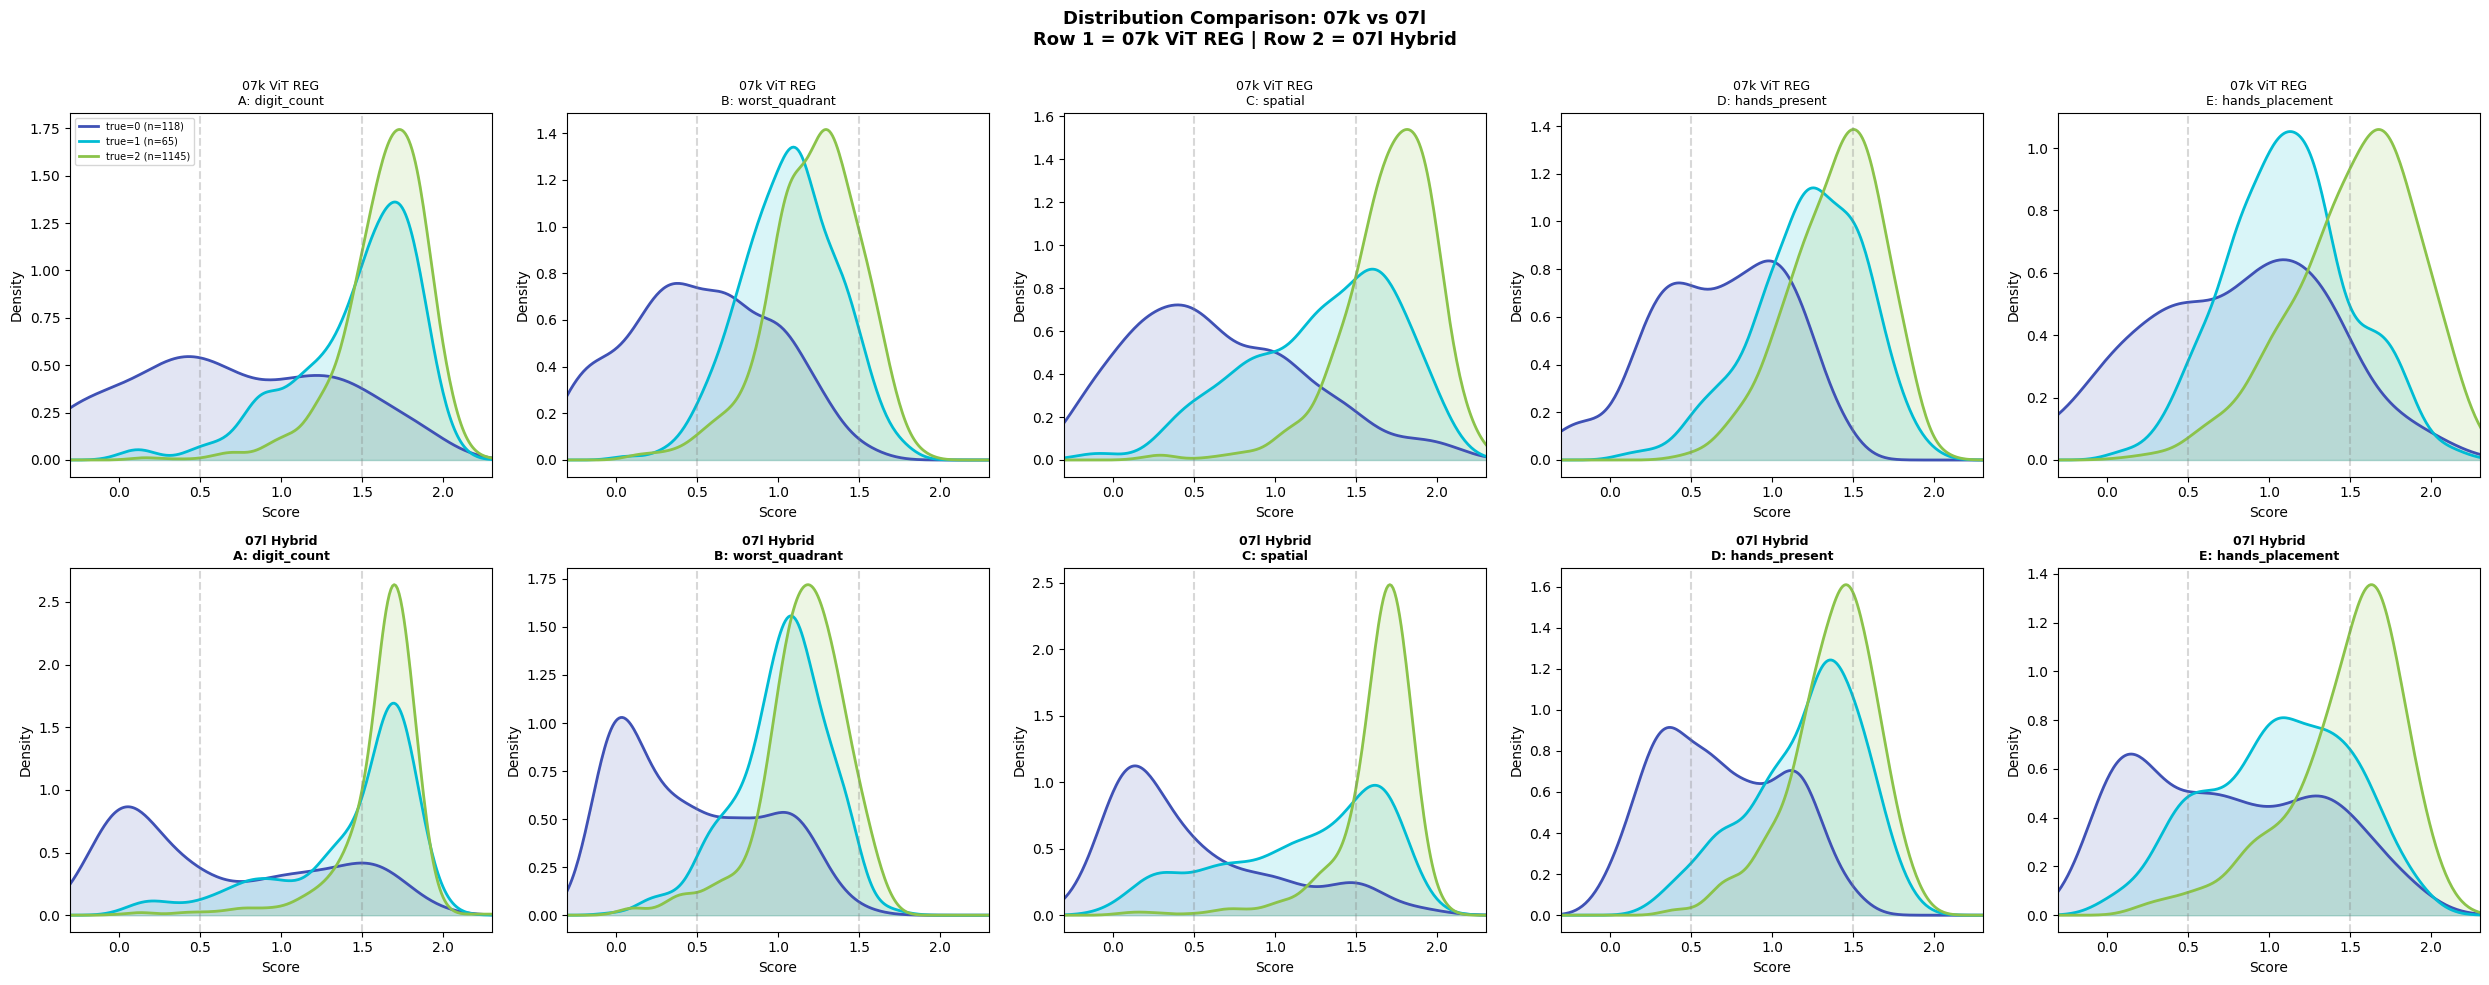

In [ ]:
vit_reg_path = (
    f'{BASE}/models_human_undersample/'
    f'human_us_vit_reg_best.pth'
)

from torchvision import models
import timm

vit_model = CDTModel(backbone_name='vit').to(device)
vit_model.load_state_dict(
    torch.load(vit_reg_path, map_location=device)
)
vit_model.eval()

test_ds_plain = CDTDataset(
    test_df, HUMAN_FOLDER, None, val_transform
)
test_loader_plain = DataLoader(
    test_ds_plain, batch_size=16, shuffle=False
)

vit_raw    = []
vit_labels = []

with torch.no_grad():
    for images, labels in test_loader_plain:
        images  = images.to(device)
        outputs = vit_model(images, mode='reg')
        raw     = torch.stack(
            [o.squeeze(-1) for o in outputs], dim=1
        )
        vit_raw.append(raw.cpu())
        vit_labels.append(labels.cpu())

vit_raw    = torch.cat(vit_raw).numpy()
vit_labels = torch.cat(vit_labels).numpy()

fig, axes = plt.subplots(
    2, 5, figsize=(25, 10)
)

for d_idx, d_name in domain_names.items():
    for row_idx, (raw, labels, title) in enumerate([
        (vit_raw,    vit_labels,    '07k ViT REG'),
        (hybrid_raw, hybrid_labels, '07l Hybrid'),
    ]):
        ax     = axes[row_idx][d_idx]
        true_d = labels[:, d_idx].astype(int)
        score_d= raw[:, d_idx]

        for true_val in [0, 1, 2]:
            mask   = (true_d == true_val)
            scores = score_d[mask]
            n      = mask.sum()
            if n < 5:
                continue

            try:
                kde    = gaussian_kde(
                    scores, bw_method=0.3
                )
                x_vals = np.linspace(-0.5, 2.5, 300)
                y_vals = kde(x_vals)
                ax.plot(
                    x_vals, y_vals,
                    color=colors_true[true_val],
                    linewidth=2,
                    label=f'true={true_val} (n={n})'
                )
                ax.fill_between(
                    x_vals, y_vals,
                    color=colors_true[true_val],
                    alpha=0.15
                )
            except:
                pass

        for x in [0.5, 1.5]:
            ax.axvline(
                x=x, color='gray',
                linestyle='--', alpha=0.3
            )

        ax.set_title(
            f'{title}\n{d_name}',
            fontsize=9,
            fontweight='bold' if row_idx==1 else 'normal'
        )
        ax.set_xlim(-0.3, 2.3)
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')

        if d_idx == 0 and row_idx == 0:
            ax.legend(fontsize=7)

plt.suptitle(
    'Distribution Comparison: 07k vs 07l\n'
    'Row 1 = 07k ViT REG | Row 2 = 07l Hybrid\n',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07l_vs_07k_distribution.png',
    dpi=150, bbox_inches='tight'
)
plt.show()